In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Build Deep Model Function**

In [ ]:
def create_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

**Train with Fixed Learning Rate**

In [ ]:
model_fixed = create_model()

optimizer = keras.optimizers.Adam(learning_rate=0.001)

model_fixed.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8772 - loss: 0.4152 - val_accuracy: 0.9599 - val_loss: 0.1329
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9677 - loss: 0.0997 - val_accuracy: 0.9643 - val_loss: 0.1211
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9790 - loss: 0.0653 - val_accuracy: 0.9643 - val_loss: 0.1232
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9840 - loss: 0.0500 - val_accuracy: 0.9754 - val_loss: 0.0862
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9881 - loss: 0.0374 - val_accuracy: 0.9732 - val_loss: 0.1028
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9742 - val_loss: 0.0980
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9921 - loss: 0.0258 - val_accuracy: 0.9752 - val_loss: 0.1003
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9926 - loss: 0.0

**Train with Learning Rate Scheduling**

In [ ]:
model_lr = create_model()

model_lr.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history_lr = model_lr.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_scheduler]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8719 - loss: 0.4303 - val_accuracy: 0.9585 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9692 - loss: 0.0997 - val_accuracy: 0.9662 - val_loss: 0.1103 - learning_rate: 0.0010
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9794 - loss: 0.0652 - val_accuracy: 0.9718 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9839 - loss: 0.0486 - val_accuracy: 0.9719 - val_loss: 0.0912 - learning_rate: 0.0010
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9873 - loss: 0.0385 - val_accuracy: 0.9761 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9900 - loss: 0.0304 - val_accuracy: 0.9746 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 7/20
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.99

**Train with Early Stopping**

In [ ]:
model_early = create_model()

model_early.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8732 - loss: 0.4235 - val_accuracy: 0.9620 - val_loss: 0.1209
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9686 - loss: 0.0987 - val_accuracy: 0.9697 - val_loss: 0.1004
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9801 - loss: 0.0629 - val_accuracy: 0.9700 - val_loss: 0.1061
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9850 - loss: 0.0481 - val_accuracy: 0.9697 - val_loss: 0.1078
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9863 - loss: 0.0405 - val_accuracy: 0.9737 - val_loss: 0.0945
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9900 - loss: 0.0296 - val_accuracy: 0.9699 - val_loss: 0.1183
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9737 - val_loss: 0.1137
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9929 - loss: 0.

Plot Comparison

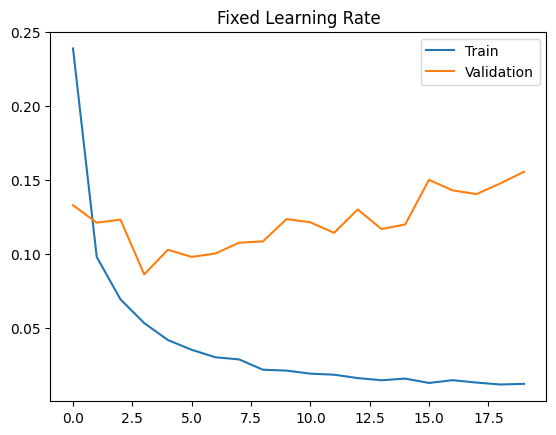

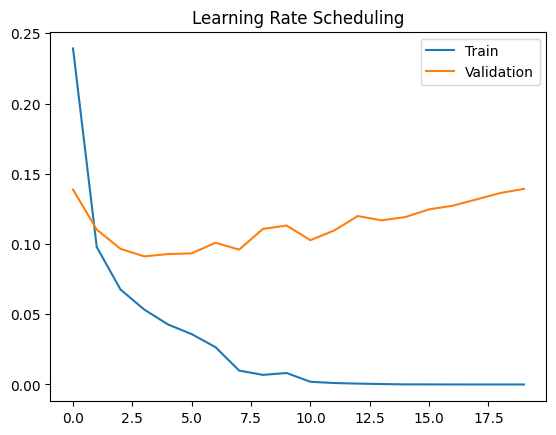

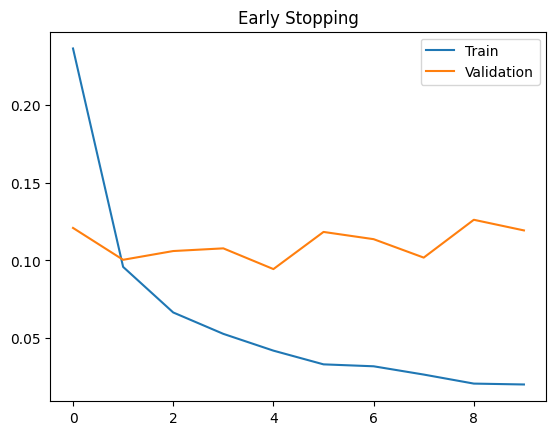

In [ ]:
def plot_loss(history, title):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.legend(['Train','Validation'])
    plt.show()

plot_loss(history_fixed, "Fixed Learning Rate")
plot_loss(history_lr, "Learning Rate Scheduling")
plot_loss(history_early, "Early Stopping")

**Print Epoch Comparison**

In [ ]:
print("Fixed LR Epochs:", len(history_fixed.history['loss']))
print("LR Scheduler Epochs:", len(history_lr.history['loss']))
print("Early Stopping Epochs:", len(history_early.history['loss']))

Fixed LR Epochs: 20
LR Scheduler Epochs: 20
Early Stopping Epochs: 10
